In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [2]:
df = pd.read_csv('data/monkey_observations.csv')
df.shape

(14, 19)

In [3]:
df.head(20)

,Fechas,Horario,Lugar,Tiempo Observación (minutos),AC,AUC,JU,DB,CA,CB,DO,RE,PA,FO,SA,SP,AI,AMC,AG
0,27-Jul,mañana,evergreen,10,0,0,1,1,1,2,0,0,0,3,0,0,2,0,0
1,03-ago,mañana,evergreen,5,0,0,0,0,2,1,0,0,0,2,0,0,1,0,0
2,26-ago,tarde,sendero jaguar,5,0,1,0,2,2,0,0,0,0,3,0,0,3,1,0
3,12-Sep,mañana,sendero jaguar,20,0,2,0,7,10,0,0,0,0,9,0,0,0,0,0
4,13-Sep,mañana,sendero jaguar,20,3,2,1,4,7,0,0,2,0,2,0,0,2,0,0
5,17-Sep,mañana,sendero jaguar,31,0,4,0,4,24,0,0,0,0,17,0,0,1,0,0
6,20-Sep,tarde,evergreen,40,3,3,0,2,19,12,0,6,4,14,2,0,1,2,0
7,21-Sep,mañana,sendero jaguar,20,3,6,0,6,15,0,0,6,7,4,0,0,1,0,0
8,22-Sep,tarde,evergreen,10,0,1,0,1,4,6,0,0,0,0,3,0,2,0,0
9,23-Sep,mañana,sendero jaguar,25,0,0,1,13,26,0,0,0,5,8,0,0,1,0,0


In [4]:
df.describe()

,Tiempo Observación (minutos),AC,AUC,JU,DB,CA,CB,DO,RE,PA,FO,SA,SP,AI,AMC,AG
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.0,14.000000,14.000000,14.000000,14.000000,14.0,14.000000,14.000000,14.0
mean,18.642857,0.785714,2.214286,0.285714,4.500000,10.857143,2.928571,0.0,1.428571,2.714286,5.785714,0.928571,0.0,1.214286,0.428571,0.0
std,10.104128,1.311404,2.359223,0.468807,3.368405,8.645649,4.531332,0.0,2.173770,3.582620,5.323079,1.639150,0.0,0.892582,0.937614,0.0
min,5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
25%,10.000000,0.000000,1.000000,0.000000,2.000000,2.500000,0.000000,0.0,0.000000,0.000000,2.000000,0.000000,0.0,1.000000,0.000000,0.0
50%,20.000000,0.000000,1.500000,0.000000,4.500000,8.500000,0.000000,0.0,0.000000,0.500000,3.500000,0.000000,0.0,1.000000,0.000000,0.0
75%,23.750000,1.500000,2.750000,0.750000,6.000000,18.000000,5.000000,0.0,2.000000,4.750000,8.750000,1.500000,0.0,2.000000,0.000000,0.0
max,40.000000,3.000000,8.000000,1.000000,13.000000,26.000000,12.000000,0.0,6.000000,11.000000,17.000000,5.000000,0.0,3.000000,3.000000,0.0


In [5]:
monkey_behaviors = {
    'AC': 'Acicalar en conjunto',
    'AUC': 'Autoacicalamiento',
    'JU': 'Jugar',
    'DB': 'Desplazar por brincos',
    'CA': 'Caminata alta',
    'CB': 'Caminata baja',
    'DO': 'Dormir',
    'RE': 'Reposo',
    'PA': 'Quieto',
    'FO': 'Forrajear',
    'SA': 'Suministro Activo',
    'SP': 'Suministro Pasivo',
    'AI': 'Amenaza',
    'AMC': 'Amenaza conjunta',
    'AG': 'Agresión'
}


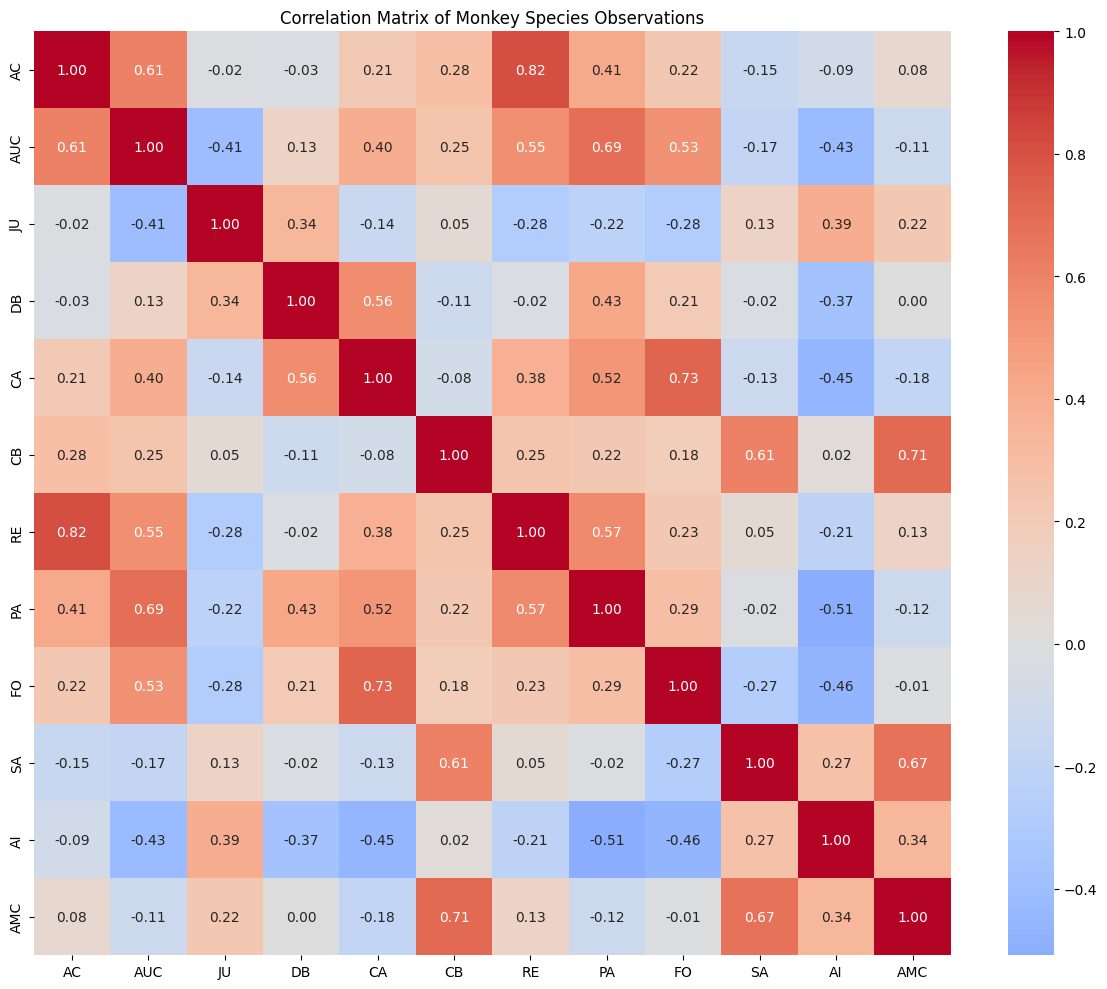

In [6]:
variable_columns = ['AC', 'AUC', 'JU', 'DB', 'CA', 'CB', 'RE', 'PA', 'FO', 'SA', 'AI', 'AMC']

# Calculate correlation matrix
corr_matrix = df[variable_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Monkey Species Observations')
plt.tight_layout()
plt.show()

In [35]:
def highlight_correlation_by_variables(corr_matrix, variable_pairs_orange=None, variable_pairs_green=None, 
                                    border_width=3):
    """
    Border specific variable pairs in the correlation matrix with different colors.
    
    Parameters:
    - corr_matrix: pandas DataFrame correlation matrix
    - variable_pairs_orange: list of tuples with variable names to border in orange
    - variable_pairs_green: list of tuples with variable names to border in green
    - border_width: width of the border line
    """
    plt.figure(figsize=(12, 10))
    
    # Create the base heatmap
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    
    # Function to add borders for a list of pairs
    def add_borders(variable_pairs, border_color):
        if variable_pairs:
            for var1, var2 in variable_pairs:
                if var1 in corr_matrix.index and var2 in corr_matrix.columns:
                    row_idx = corr_matrix.index.get_loc(var1)
                    col_idx = corr_matrix.columns.get_loc(var2)
                    
                    # Correct coordinate calculation for heatmap
                    y_pos = row_idx + 0.5
                    x_pos = col_idx + 0.5
                    
                    plt.gca().add_patch(plt.Rectangle((x_pos-0.5, y_pos-0.5), 1, 1, 
                                                    fill=False, edgecolor=border_color, 
                                                    linewidth=border_width))
    
    # Add orange borders (stronger orange)
    add_borders(variable_pairs_orange, '#b33b72')  # Dark orange
    
    # Add green borders
    add_borders(variable_pairs_green, 'green')
    
    plt.title('Correlation Matrix of Monkey Species Observations')
    plt.tight_layout()
    plt.show()

In [40]:
def highlight_correlation_by_variables(corr_matrix, variable_pairs_orange=None, variable_pairs_green=None, 
                                    border_width=3):
    """
    Border specific variable pairs in the correlation matrix with different colors.
    
    Parameters:
    - corr_matrix: pandas DataFrame correlation matrix
    - variable_pairs_orange: list of tuples with variable names to border in orange
    - variable_pairs_green: list of tuples with variable names to border in green
    - border_width: width of the border line
    """
    plt.figure(figsize=(12, 10))
    
    # Create the base heatmap
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    
    # Function to add borders using individual line segments
    def add_borders(variable_pairs, border_color):
        if variable_pairs:
            for var1, var2 in variable_pairs:
                if var1 in corr_matrix.index and var2 in corr_matrix.columns:
                    row_idx = corr_matrix.index.get_loc(var1)
                    col_idx = corr_matrix.columns.get_loc(var2)
                    
                    # Correct coordinate calculation for heatmap
                    y_pos = row_idx + 0.5
                    x_pos = col_idx + 0.5
                    
                    # Create individual line segments for each side
                    # Top border
                    plt.plot([x_pos-0.5, x_pos+0.5], [y_pos+0.5, y_pos+0.5], 
                            color=border_color, linewidth=border_width)
                    # Bottom border
                    plt.plot([x_pos-0.5, x_pos+0.5], [y_pos-0.5, y_pos-0.5], 
                            color=border_color, linewidth=border_width)
                    # Left border
                    plt.plot([x_pos-0.5, x_pos-0.5], [y_pos-0.5, y_pos+0.5], 
                            color=border_color, linewidth=border_width)
                    # Right border
                    plt.plot([x_pos+0.5, x_pos+0.5], [y_pos-0.5, y_pos+0.5], 
                            color=border_color, linewidth=border_width)
    
    # Add orange borders
    add_borders(variable_pairs_orange, '#a3386c')
    
    # Add green borders
    add_borders(variable_pairs_green, 'green')
    
    plt.title('Correlation Matrix of Monkey Species Observations')
    plt.tight_layout()
    plt.show()

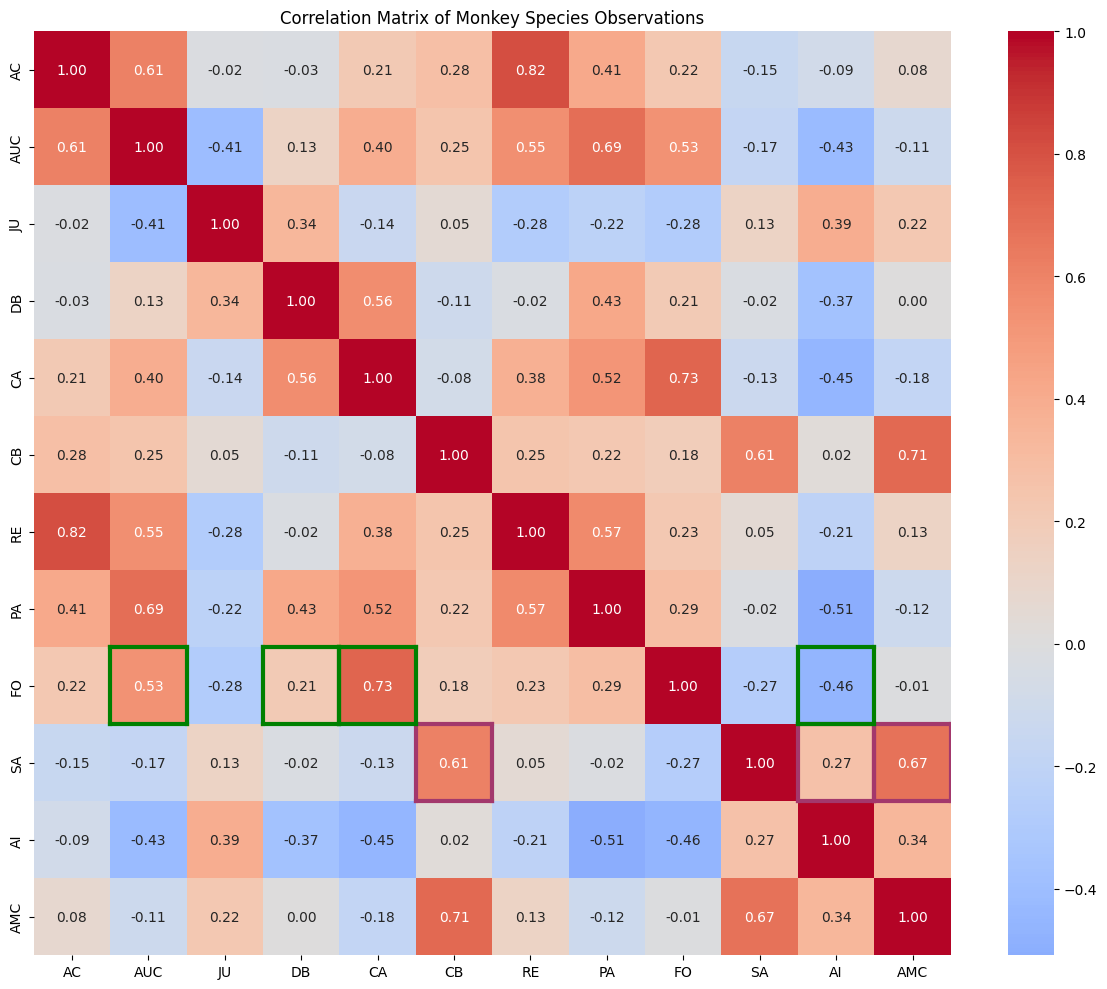

In [41]:
# Example usage with two different lists:
orange_pairs = [('SA', 'CB'), ('SA', 'AMC'), ('SA', 'AI')]
green_pairs = [('FO', 'CA'), ('FO', 'AUC'), ('FO', 'DB'), ('FO', 'AI')]
highlight_correlation_by_variables(corr_matrix, variable_pairs_orange=orange_pairs, 
                                variable_pairs_green=green_pairs)

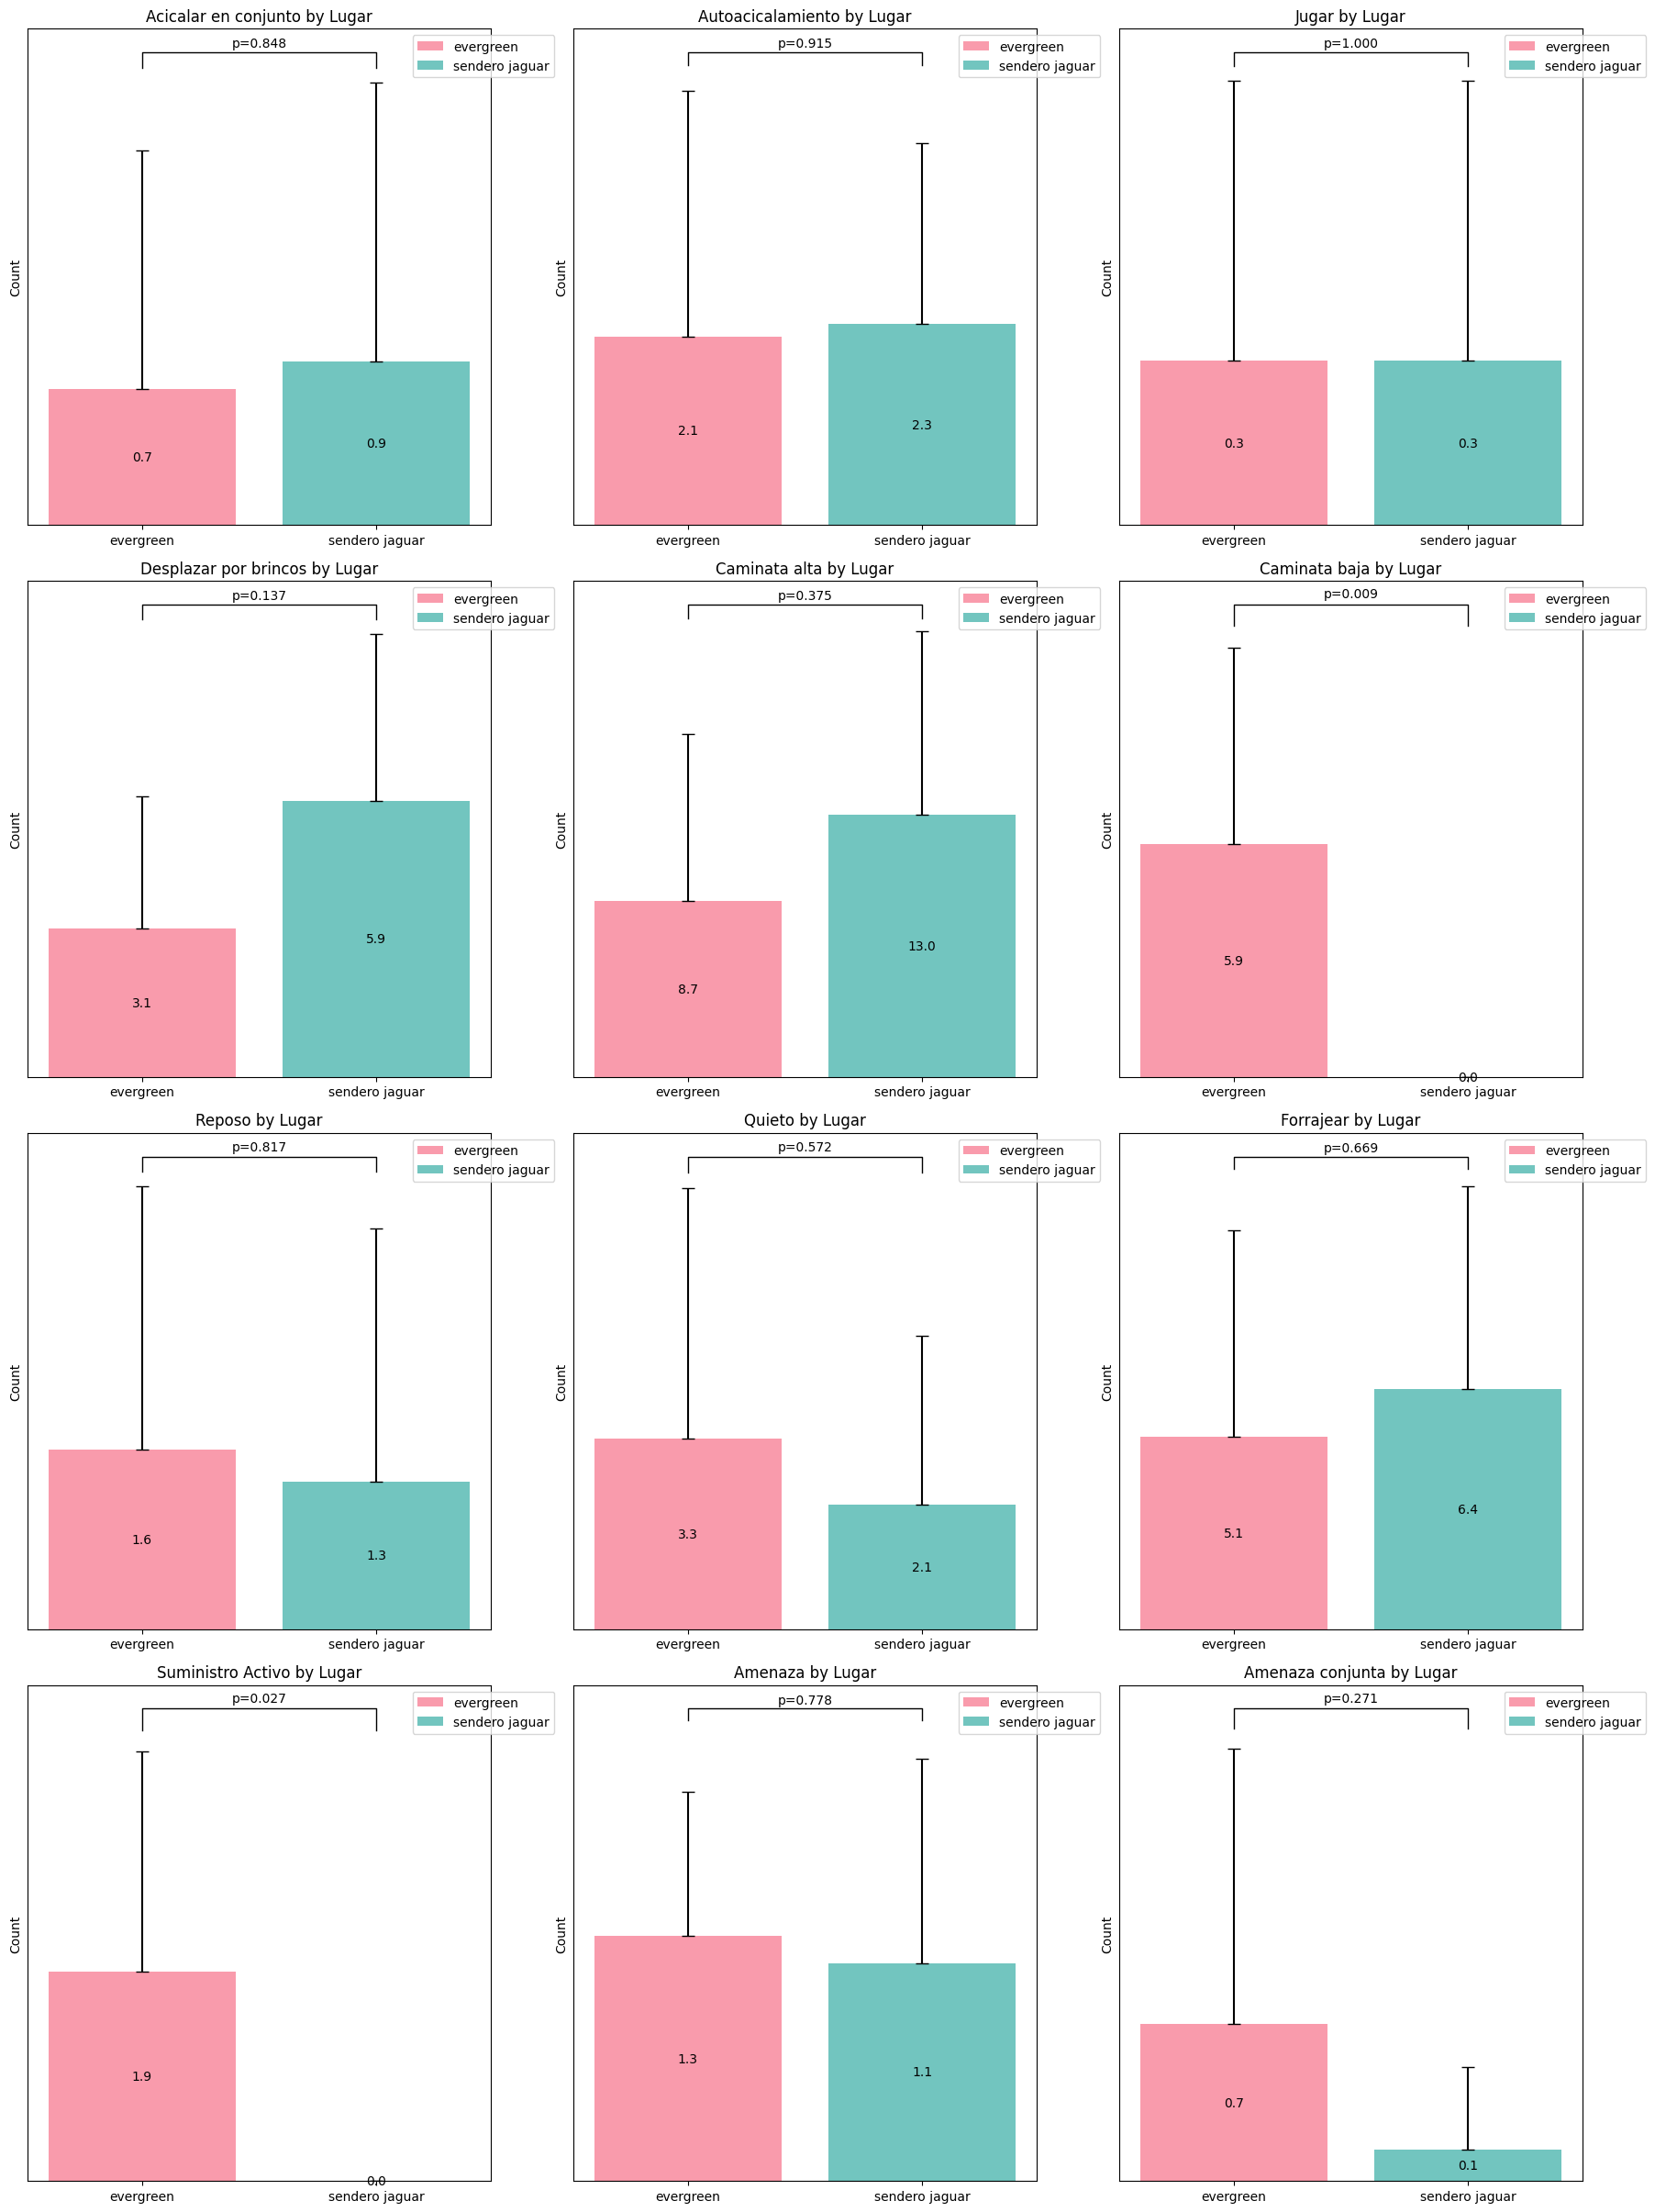

In [42]:
def analyze_by_category(df, category_col, value_cols, columns_to_check=None, significance_threshold=0.05):
    """
    Analyze differences in value columns grouped by a category column.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe
    category_col : str
        Column name to group by
    value_cols : list
        List of column names to analyze
    columns_to_check : list, optional
        List of specific columns to check for statistical significance
    significance_threshold : float, default=0.05
        P-value threshold for statistical significance
    """
    categories = df[category_col].unique()
    colors = sns.color_palette("husl", len(categories))
    
    # Create a 5x3 grid of subplots
    n_rows = 5
    n_cols = 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 30))
    axes = axes.flatten()
    
    # Create bar plots for each variable
    for idx, col in enumerate(value_cols):
        if idx < len(axes):  # Ensure we don't exceed the number of subplots
            ax = axes[idx]
            
            # Calculate means and standard deviations
            means = [df[df[category_col] == cat][col].mean() for cat in categories]
            stds = [df[df[category_col] == cat][col].std() for cat in categories]
            
            # Create bar plot with only top error bars
            bars = ax.bar(range(len(categories)), means, 
                         yerr=[np.zeros_like(stds), stds],  # Only show top error bars
                         capsize=5, color=colors, alpha=0.7)
            
            # Add mean values below each bar
            for i, mean in enumerate(means):
                ax.text(i, mean/2, f'{mean:.1f}', ha='center', va='center')
            
            # Add simple legend with just category names
            legend_elements = []
            for i, cat in enumerate(categories):
                legend_elements.append(plt.Rectangle((0,0),1,1, fc=colors[i], alpha=0.7,
                                                   label=cat))
            ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
            
            # Calculate and display p-values if columns_to_check is specified
            if columns_to_check and col in columns_to_check:
                y_max = max(means) + max(stds)
                y_range = y_max - min(means)
                y_offset = y_range * 0.05
                
                for i in range(len(categories)):
                    for j in range(i+1, len(categories)):
                        cat1 = df[df[category_col] == categories[i]][col]
                        cat2 = df[df[category_col] == categories[j]][col]
                        
                        t_stat, p_val = stats.ttest_ind(cat1, cat2)
                        
                        # Draw bracket
                        ax.plot([i, i, j, j], 
                               [y_max + y_offset, y_max + y_offset*2, y_max + y_offset*2, y_max + y_offset], 
                               'k-', lw=1)
                        
                        # Add p-value text
                        ax.text((i + j)/2, y_max + y_offset*2.2, 
                               f'p={p_val:.3f}', 
                               ha='center', va='bottom')
            
            # Use the full name from monkey_behaviors dictionary for the title
            behavior_name = monkey_behaviors.get(col, col)
            ax.set_title(f'{behavior_name} by {category_col}')
            ax.set_xticks(range(len(categories)))
            ax.set_xticklabels(categories, rotation=0)  # Changed rotation to 0 for horizontal labels
            ax.set_ylabel('Count')
            
            # Remove y-axis scale numbers
            ax.set_yticks([])
    
    # Hide any unused subplots
    for idx in range(len(value_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Example usage:
analyze_by_category(df, 'Lugar', variable_columns, columns_to_check=variable_columns)